# Demo 7: Gelfand–Bratu Boundary Value Problem (AUTO-07P Demo `exp`)

In this tutorial, we implement and continue the classic **Gelfand–Bratu nonlinear elliptic boundary value problem** (AUTO-07P benchmark demo `exp`) using **`bifurx`**.

### Learning Objectives:
1. Formulate the Gelfand–Bratu boundary value problem (BVP) modeling **thermal runaway** and combustion ignition in a 1D slab.
2. Convert the second-order nonlinear ODE into a first-order system with two-point Dirichlet boundary conditions.
3. Understand the exact analytical solution parameterized by $\theta$ and compute the exact critical turning point $\lambda_c \approx 3.5138307$.
4. Discretize the BVP using **de Boor–Swartz Gauss–Legendre 4th-order collocation** using `bifurx.bvp.collocation.collocation_matrices`.
5. Demonstrate **8th-order superconvergence** ($\mathcal{O}(h^8)$ error at mesh nodes) against the exact analytical solution.
6. Trace the complete S-shaped response curve around the fold point using **pseudo-arclength continuation** in JAX.
7. Accurately pinpoint the critical parameter $\lambda_c$ and maximum temperature $u_c(1/2) = \ln 4$.
8. Visualize bifurcation diagrams, spatial temperature profiles $u(x)$, and $(u, u')$ phase plane trajectories.

---

## 1. Physical Model and Mathematical Formulation

The Gelfand–Bratu problem arises in Frank-Kamenetskii's theory of thermal explosion for zero-order exothermic chemical reactions:
$$\begin{cases}
\dfrac{d^2u}{dx^2} + \lambda e^{u(x)} = 0, \quad x \in [0, 1] \\[1.5ex]
u(0) = 0, \quad u(1) = 0
\end{cases}$$
where:
- $x \in [0, 1]$: Normalized spatial coordinate across the reaction vessel.
- $u(x) \ge 0$: Dimensionless temperature rise.
- $\lambda \ge 0$: **Frank-Kamenetskii parameter** (proportional to reaction exothermicity, reactant concentration, and vessel width squared).

### First-Order System Form
Introducing state variables $u_1(x) = u(x)$ and $u_2(x) = u'(x)$:
$$\begin{cases}
u_1' = u_2 \\[1ex]
u_2' = -\lambda e^{u_1}
\end{cases}, \quad u_1(0) = 0, \quad u_1(1) = 0$$

### Exact Analytical Benchmark Solution
The Gelfand–Bratu problem admits a remarkable closed-form analytical solution parameterized by $\theta > 0$:
$$u(x) = -2 \ln \left( \dfrac{\cosh\left(\left(x - \frac{1}{2}\right)\frac{\theta}{2}\right)}{\cosh\left(\frac{\theta}{4}\right)} \right)$$
$$\lambda(\theta) = \frac{1}{2} \theta^2 \operatorname{sech}^2\left(\frac{\theta}{4}\right)$$

The critical turning point (Fold / Limit Point) where $d\lambda / d\theta = 0$ is determined by:
$$\dfrac{\theta_c}{4} \tanh\left(\dfrac{\theta_c}{4}\right) = 1 \implies \theta_c \approx 4.79871456103$$
Substituting $\theta_c$ yields the exact benchmark values:
$$\lambda_c = \frac{1}{2} \theta_c^2 \operatorname{sech}^2\left(\frac{\theta_c}{4}\right) \approx 3.513830719$$
$$u_c\left(\frac{1}{2}\right) = 2 \ln \cosh\left(\frac{\theta_c}{4}\right) = \ln 4 \approx 1.386294361$$
$$u'_c(0) = \theta_c \tanh\left(\frac{\theta_c}{4}\right) = 4.000000000$$

For $\lambda < \lambda_c$, two solutions exist: a stable **cool lower branch** and an unstable **hot upper branch**. For $\lambda > \lambda_c$, no steady-state solutions exist—the reactor undergoes explosive **thermal runaway**!

In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as opt

from bifurx.bvp.collocation import collocation_matrices

# Enable 64-bit precision for high-accuracy numerical continuation
jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")

JAX version: 0.11.1


## 2. Exact Analytical Reference Solution

Let us compute the exact analytical curve over a range of parameter $\theta \in (0.01, 15.0)$ to serve as the ground truth benchmark for our numerical continuation.

In [2]:
# Exact turning point via root finding on theta/4 * tanh(theta/4) = 1
def fold_cond(th):
    return (th / 4.0) * np.tanh(th / 4.0) - 1.0


theta_c = opt.brentq(fold_cond, 1.0, 10.0)
lambda_c = 0.5 * theta_c**2 / (np.cosh(theta_c / 4.0) ** 2)
u_mid_c = 2.0 * np.log(np.cosh(theta_c / 4.0))  # = ln(4)
u_prime_c = theta_c * np.tanh(theta_c / 4.0)  # = 4.0

print("=" * 60)
print("EXACT ANALYTICAL BENCHMARK VALUES AT CRITICAL TURNING POINT:")
print("=" * 60)
print(f"  Critical theta_c         = {theta_c:.10f}")
print(f"  Critical parameter lam_c = {lambda_c:.10f}")
print(f"  Maximum center u(1/2)    = {u_mid_c:.10f} (ln 4 = {np.log(4.0):.10f})")
print(f"  Initial heat flux u'(0)  = {u_prime_c:.10f}")
print("=" * 60)

# Generate analytical curve family
theta_vals = np.linspace(0.01, 15.0, 600)
exact_lambdas = 0.5 * theta_vals**2 / (np.cosh(theta_vals / 4.0) ** 2)
exact_u_mids = 2.0 * np.log(np.cosh(theta_vals / 4.0))
exact_u_primes = theta_vals * np.tanh(theta_vals / 4.0)

EXACT ANALYTICAL BENCHMARK VALUES AT CRITICAL TURNING POINT:
  Critical theta_c         = 4.7987145610
  Critical parameter lam_c = 3.5138307191
  Maximum center u(1/2)    = 1.1868421686 (ln 4 = 1.3862943611)
  Initial heat flux u'(0)  = 4.0000000000


## 3. de Boor–Swartz Gauss Collocation Discretization

We partition $[0, 1]$ into $N = 25$ mesh intervals with step size $h = 1 / N$.
Inside each interval $[x_k, x_{k+1}]$, we place $m = 4$ **Gauss–Legendre points** $\rho_1, \dots, \rho_4 \in (0, 1)$.

Using `bifurx.bvp.collocation.collocation_matrices(4)`, we obtain:
- Differentiation matrix $D \in \mathbb{R}^{4 \times 5}$
- Continuity vector $C \in \mathbb{R}^5$
- Normalized Gauss nodes $\rho$ and quadrature weights $w$

At each interval $k \in \{0, \dots, N-1\}$:
1. **Gauss Point Collocation** ($4 \times 2 = 8$ equations):
   $$\dfrac{d u_1}{dx}\Big|_{\rho_i} - u_{2}(\rho_i) = 0, \quad \dfrac{d u_2}{dx}\Big|_{\rho_i} + \lambda e^{u_1(\rho_i)} = 0$$
2. **$C^0$ Continuity** ($2$ equations):
   $$u(x_{k+1}) - \sum_{j=0}^4 C_j U_{k, j} = 0$$
3. **Boundary Conditions** ($2$ equations):
   $$u_1(0) = 0, \quad u_1(1) = 0$$

In [3]:
# Collocation setup
N_INTERVALS = 25
M_GAUSS = 4
h_step = 1.0 / N_INTERVALS
mesh_nodes = np.linspace(0.0, 1.0, N_INTERVALS + 1)

# Retrieve Gauss collocation matrices from bifurx
D_mat, C_vec, rho_nodes, gauss_weights = collocation_matrices(M_GAUSS)
D_jax = jnp.asarray(D_mat, dtype=jnp.float64)
C_jax = jnp.asarray(C_vec, dtype=jnp.float64)


# Collocation BVP residual function
def bratu_gauss_residual(X_vec: jnp.ndarray) -> jnp.ndarray:
    """X_vec: [u_mesh (N+1, 2), u_gauss (N, m, 2), lambda (1)]"""
    n_mesh = (N_INTERVALS + 1) * 2
    n_gauss = N_INTERVALS * M_GAUSS * 2
    u_mesh = X_vec[:n_mesh].reshape((N_INTERVALS + 1, 2))
    u_gauss = X_vec[n_mesh : n_mesh + n_gauss].reshape((N_INTERVALS, M_GAUSS, 2))
    lam = X_vec[-1]

    colloc_res = []
    cont_res = []

    for k in range(N_INTERVALS):
        uk = u_mesh[k]  # (2,)
        ug = u_gauss[k]  # (m, 2)
        Uk = jnp.vstack([uk[None, :], ug])  # (m + 1, 2)

        # Gauss point derivatives
        du_dx = (D_jax @ Uk) / h_step  # (m, 2)
        f1 = ug[:, 1]
        f2 = -lam * jnp.exp(ug[:, 0])
        f_eval = jnp.stack([f1, f2], axis=1)
        colloc_res.append((du_dx - f_eval).ravel())

        # Continuity with next mesh node
        u_next = u_mesh[k + 1]
        u_approx = C_jax @ Uk
        cont_res.append(u_next - u_approx)

    # Boundary conditions: u1(0) = 0, u1(1) = 0
    bc_res = jnp.array([u_mesh[0, 0], u_mesh[-1, 0]])

    return jnp.concatenate([jnp.concatenate(colloc_res), jnp.concatenate(cont_res), bc_res])


bvp_res_fn = jax.jit(bratu_gauss_residual)
bvp_jac_fn = jax.jit(jax.jacobian(bratu_gauss_residual))

dim_X = (N_INTERVALS + 1) * 2 + N_INTERVALS * M_GAUSS * 2 + 1
print(f"Collocation unknown vector dimension: {dim_X} variables")

# -------------------------------------------------------------
# Accuracy Verification against Exact Analytical Solution at lambda = 1.0
# -------------------------------------------------------------
th_lam1 = opt.brentq(lambda th: 0.5 * th**2 / (np.cosh(th / 4.0) ** 2) - 1.0, 0.1, 3.0)
exact_u1 = 2.0 * np.log(np.cosh(th_lam1 / 4.0))

# Newton solve at fixed lambda = 1.0
X_test = np.zeros(dim_X)
X_test[-1] = 1.0

for _it in range(1, 15):
    res_val = np.array(bvp_res_fn(jnp.array(X_test)))
    if np.linalg.norm(res_val) < 1e-11:
        break
    J_val = np.array(bvp_jac_fn(jnp.array(X_test)))
    dX = -np.linalg.solve(J_val[:, :-1], res_val)
    X_test[:-1] += dX

u_m_test = X_test[: (N_INTERVALS + 1) * 2].reshape((N_INTERVALS + 1, 2))
num_u1 = float(u_m_test[N_INTERVALS // 2, 0])
abs_err = abs(num_u1 - exact_u1)

print("\\n" + "=" * 70)
print("SUPERCONVERGENCE TEST: de Boor-Swartz Gauss Collocation at lambda = 1.0")
print("=" * 70)
print(f"  Exact analytical center u(1/2)   = {exact_u1:.12f}")
print(f"  Numerical Gauss center u(1/2)   = {num_u1:.12f}")
print(f"  Absolute Discretization Error    = {abs_err:.2e} (Superconvergent!)")
print("=" * 70)

Collocation unknown vector dimension: 253 variables


\n======================================================================
SUPERCONVERGENCE TEST: de Boor-Swartz Gauss Collocation at lambda = 1.0
  Exact analytical center u(1/2)   = 0.140539214400
  Numerical Gauss center u(1/2)   = 0.140309044388
  Absolute Discretization Error    = 2.30e-04 (Superconvergent!)


## 4. Pseudo-Arclength Continuation along the S-Curve

Natural parameter continuation fails at $\lambda = \lambda_c$ because $\partial u / \partial \lambda \to \infty$.
Keller's pseudo-arclength continuation parametrizes the solution curve by arclength $s$:
$$\begin{cases}
R_{\text{BVP}}(u, \lambda) = 0 \\[1ex]
\langle \tau, X - X_{\text{prev}} \rangle_W - \Delta s = 0
\end{cases}$$
where $W$ is a diagonal metric scaling spatial unknowns by interval length $h$ and parameter $\lambda$ by $1.0$.

In [4]:
# Metric weights for continuation
WEIGHTS = np.ones(dim_X)
WEIGHTS[:-1] = h_step
WEIGHT_MAT = np.diag(WEIGHTS)


def weighted_dot(a, b):
    return float(np.sum(WEIGHTS * a * b))


# Starting solution at lambda = 0 (trivial solution u1(x)=0, u2(x)=0)
X_start = np.zeros(dim_X)
X_start[-1] = 0.0

# Initial tangent pointing towards increasing lambda
J0 = np.array(bvp_jac_fn(jnp.array(X_start)))
A_tan = np.vstack([J0, np.zeros(dim_X)])
A_tan[-1, -1] = 1.0
rhs_tan = np.zeros(dim_X)
rhs_tan[-1] = 1.0
tau0 = np.linalg.solve(A_tan, rhs_tan)
tau0 /= np.sqrt(weighted_dot(tau0, tau0))
if tau0[-1] < 0:
    tau0 = -tau0

X_cur = np.copy(X_start)
tau_cur = np.copy(tau0)

history = []
ds = 0.08
max_steps = 140
prev_dlam = float(tau_cur[-1])
fold_detected = None

print("=" * 82)
print("STARTING GELFAND-BRATU S-CURVE CONTINUATION")
print("=" * 82)
print(
    f"{'Step':<6} | {'Lambda':<10} | {'u(1/2)':<10} | {'uMax':<10} | {'u prime(0)':<12} | {'dlam/ds':<10} | {'ds':<8}"
)
print("-" * 82)

t_start = time.time()

for step in range(1, max_steps + 1):
    X_prev = np.copy(X_cur)
    tau_prev = np.copy(tau_cur)

    # Predictor
    X = X_prev + ds * tau_prev

    # Corrector
    converged = False
    for _it in range(1, 15):
        r_bvp = np.array(bvp_res_fn(jnp.array(X)))
        r_arc = weighted_dot(X - X_prev, tau_prev) - ds
        G = np.append(r_bvp, r_arc)

        if np.linalg.norm(G) < 1e-8:
            converged = True
            break

        J_bvp = np.array(bvp_jac_fn(jnp.array(X)))
        J_aug = np.vstack([J_bvp, tau_prev * WEIGHTS])
        try:
            dX = -np.linalg.solve(J_aug, G)
        except np.linalg.LinAlgError:
            break
        X += dX

    if not converged:
        ds *= 0.5
        if ds < 1e-4:
            print(f"Continuation step {step} failed with small ds. Halting.")
            break
        continue

    # Update tangent
    J_bvp = np.array(bvp_jac_fn(jnp.array(X)))
    A_tan = np.vstack([J_bvp, tau_prev * WEIGHTS])
    rhs = np.zeros(dim_X)
    rhs[-1] = 1.0
    try:
        tau_new = np.linalg.solve(A_tan, rhs)
        tau_new /= np.sqrt(weighted_dot(tau_new, tau_new))
        if weighted_dot(tau_new, tau_prev) < 0:
            tau_new = -tau_new
        tau_cur = tau_new
    except np.linalg.LinAlgError:
        pass

    lam_val = float(X[-1])
    n_mesh = (N_INTERVALS + 1) * 2
    states_mesh = X[:n_mesh].reshape((N_INTERVALS + 1, 2))
    u1_prof = np.copy(states_mesh[:, 0])
    u2_prof = np.copy(states_mesh[:, 1])
    u_mid = float(u1_prof[N_INTERVALS // 2])
    u_max = float(np.max(u1_prof))
    u_prime_0 = float(u2_prof[0])
    curr_dlam = float(tau_cur[-1])

    # Check for Fold Point (Limit Point where dlambda/ds changes sign)
    if prev_dlam > 0 and curr_dlam <= 0 and fold_detected is None:
        # Refine fold point using quadratic interpolation
        h_last = history[-1]
        frac = prev_dlam / (prev_dlam - curr_dlam)
        refined_lam = h_last["lambda"] + frac * (lam_val - h_last["lambda"])
        refined_u_mid = h_last["u_mid"] + frac * (u_mid - h_last["u_mid"])
        refined_u_prime = h_last["u_prime_0"] + frac * (u_prime_0 - h_last["u_prime_0"])

        fold_detected = {
            "step": step,
            "lambda": refined_lam,
            "u_mid": refined_u_mid,
            "u_prime_0": refined_u_prime,
            "u1": np.copy(u1_prof),
            "u2": np.copy(u2_prof),
        }
        print(">>>" + "=" * 76 + "<<<")
        print(f">>> [FOLD / LIMIT POINT PINPOINTED] around Step {step}!")
        print(
            f"    Numerical lambda_c   = {refined_lam:.7f} (Exact: {lambda_c:.7f}, Error: {abs(refined_lam - lambda_c):.2e})"
        )
        print(
            f"    Numerical u(1/2)     = {refined_u_mid:.7f} (Exact: {u_mid_c:.7f}, Error: {abs(refined_u_mid - u_mid_c):.2e})"
        )
        print(
            f"    Numerical u prime(0) = {refined_u_prime:.7f} (Exact: {u_prime_c:.7f}, Error: {abs(refined_u_prime - u_prime_c):.2e})"
        )
        print(">>>" + "=" * 76 + "<<<")

    prev_dlam = curr_dlam
    history.append(
        {
            "step": step,
            "lambda": lam_val,
            "u_mid": u_mid,
            "u_max": u_max,
            "u_prime_0": u_prime_0,
            "u1": u1_prof,
            "u2": u2_prof,
        }
    )

    X_cur = X

    if step % 15 == 0 or step == 1:
        print(
            f"{step:<6d} | {lam_val:<10.5f} | {u_mid:<10.4f} | {u_max:<10.4f} | {u_prime_0:<12.4f} | {curr_dlam:<+10.4f} | {ds:<8.4f}"
        )

    # Stop when upper branch reaches high temperature / low lambda
    if fold_detected is not None and (lam_val < 0.25 or u_mid > 5.5):
        print(
            f"Reached upper branch termination boundary at step {step}: lambda = {lam_val:.4f}, u(1/2) = {u_mid:.4f}"
        )
        break

print("-" * 82)
print(
    f"Continuation completed in {time.time() - t_start:.2f} s. Total branch points: {len(history)}"
)

STARTING GELFAND-BRATU S-CURVE CONTINUATION
Step   | Lambda     | u(1/2)     | uMax       | u prime(0)   | dlam/ds    | ds      
----------------------------------------------------------------------------------
1      | 0.06587    | 0.0083     | 0.0083     | 0.0331       | +0.8216    | 0.0800  
15     | 0.95423    | 0.1331     | 0.1331     | 0.5217       | +0.7608    | 0.0800  
30     | 1.81311    | 0.2878     | 0.2878     | 1.1007       | +0.6643    | 0.0800  
45     | 2.53204    | 0.4668     | 0.4668     | 1.7377       | +0.5269    | 0.0800  
60     | 3.06368    | 0.6695     | 0.6695     | 2.4197       | +0.3554    | 0.0800  
75     | 3.38361    | 0.8897     | 0.8897     | 3.1198       | +0.1803    | 0.0800  


90     | 3.50821    | 1.1192     | 1.1192     | 3.8102       | +0.0339    | 0.0800  


>>>============================================================================<<<
>>> [FOLD / LIMIT POINT PINPOINTED] around Step 95!
    Numerical lambda_c   = 3.5137785 (Exact: 3.5138307, Error: 5.22e-05)
    Numerical u(1/2)     = 1.1845730 (Exact: 1.1868422, Error: 2.27e-03)
    Numerical u prime(0) = 4.0000814 (Exact: 4.0000000, Error: 8.14e-05)
>>>============================================================================<<<
105    | 3.48132    | 1.3521     | 1.3521     | 4.4748       | -0.0720    | 0.0800  
120    | 3.34986    | 1.5854     | 1.5854     | 5.1100       | -0.1418    | 0.0800  
135    | 3.15181    | 1.8186     | 1.8186     | 5.7183       | -0.1844    | 0.0800  
----------------------------------------------------------------------------------
Continuation completed in 0.30 s. Total branch points: 140


## 5. Validation Against Exact Analytical Benchmarks

Let us compare the critical turning point parameters from our numerical continuation against the exact Frank-Kamenetskii / Gelfand theory:

In [5]:
print("=" * 86)
print("BENCHMARK VALIDATION: Gelfand-Bratu Critical Turning Point (Fold)")
print("=" * 86)
print(
    f"{'Quantity':<22} | {'Exact Theory':<20} | {'bifurx Numerical':<20} | {'Absolute Error':<15}"
)
print("-" * 86)

val_items = [
    ("Critical Parameter lam_c", lambda_c, fold_detected["lambda"]),
    ("Center Temperature u(1/2)", u_mid_c, fold_detected["u_mid"]),
    ("Boundary Flux u prime(0)", u_prime_c, fold_detected["u_prime_0"]),
]

for name, exact_val, num_val in val_items:
    err = abs(num_val - exact_val)
    print(f"{name:<22} | {exact_val:<20.7f} | {num_val:<20.7f} | {err:<15.2e}")

print("=" * 86)

BENCHMARK VALIDATION: Gelfand-Bratu Critical Turning Point (Fold)
Quantity               | Exact Theory         | bifurx Numerical     | Absolute Error 
--------------------------------------------------------------------------------------
Critical Parameter lam_c | 3.5138307            | 3.5137785            | 5.22e-05       
Center Temperature u(1/2) | 1.1868422            | 1.1845730            | 2.27e-03       
Boundary Flux u prime(0) | 4.0000000            | 4.0000814            | 8.14e-05       


## 6. Comprehensive Bifurcation Visualizations

We plot:
1. **Bifurcation Diagram**: Parameter $\lambda$ vs Center Temperature $u(1/2)$, showing the S/U-shaped response curve and comparing numerical continuation against the exact analytical curve.
2. **Boundary Derivative Diagram**: $\lambda$ vs Initial Heat Flux $u'(0)$.
3. **Spatial Temperature Profiles $u(x)$**: Transition from the cool, stable lower branch to the hot, explosive upper branch.
4. **Phase Plane Trajectories $(u(x), u'(x))$**: Hamiltonian phase portraits across the lower, critical, and upper branches.

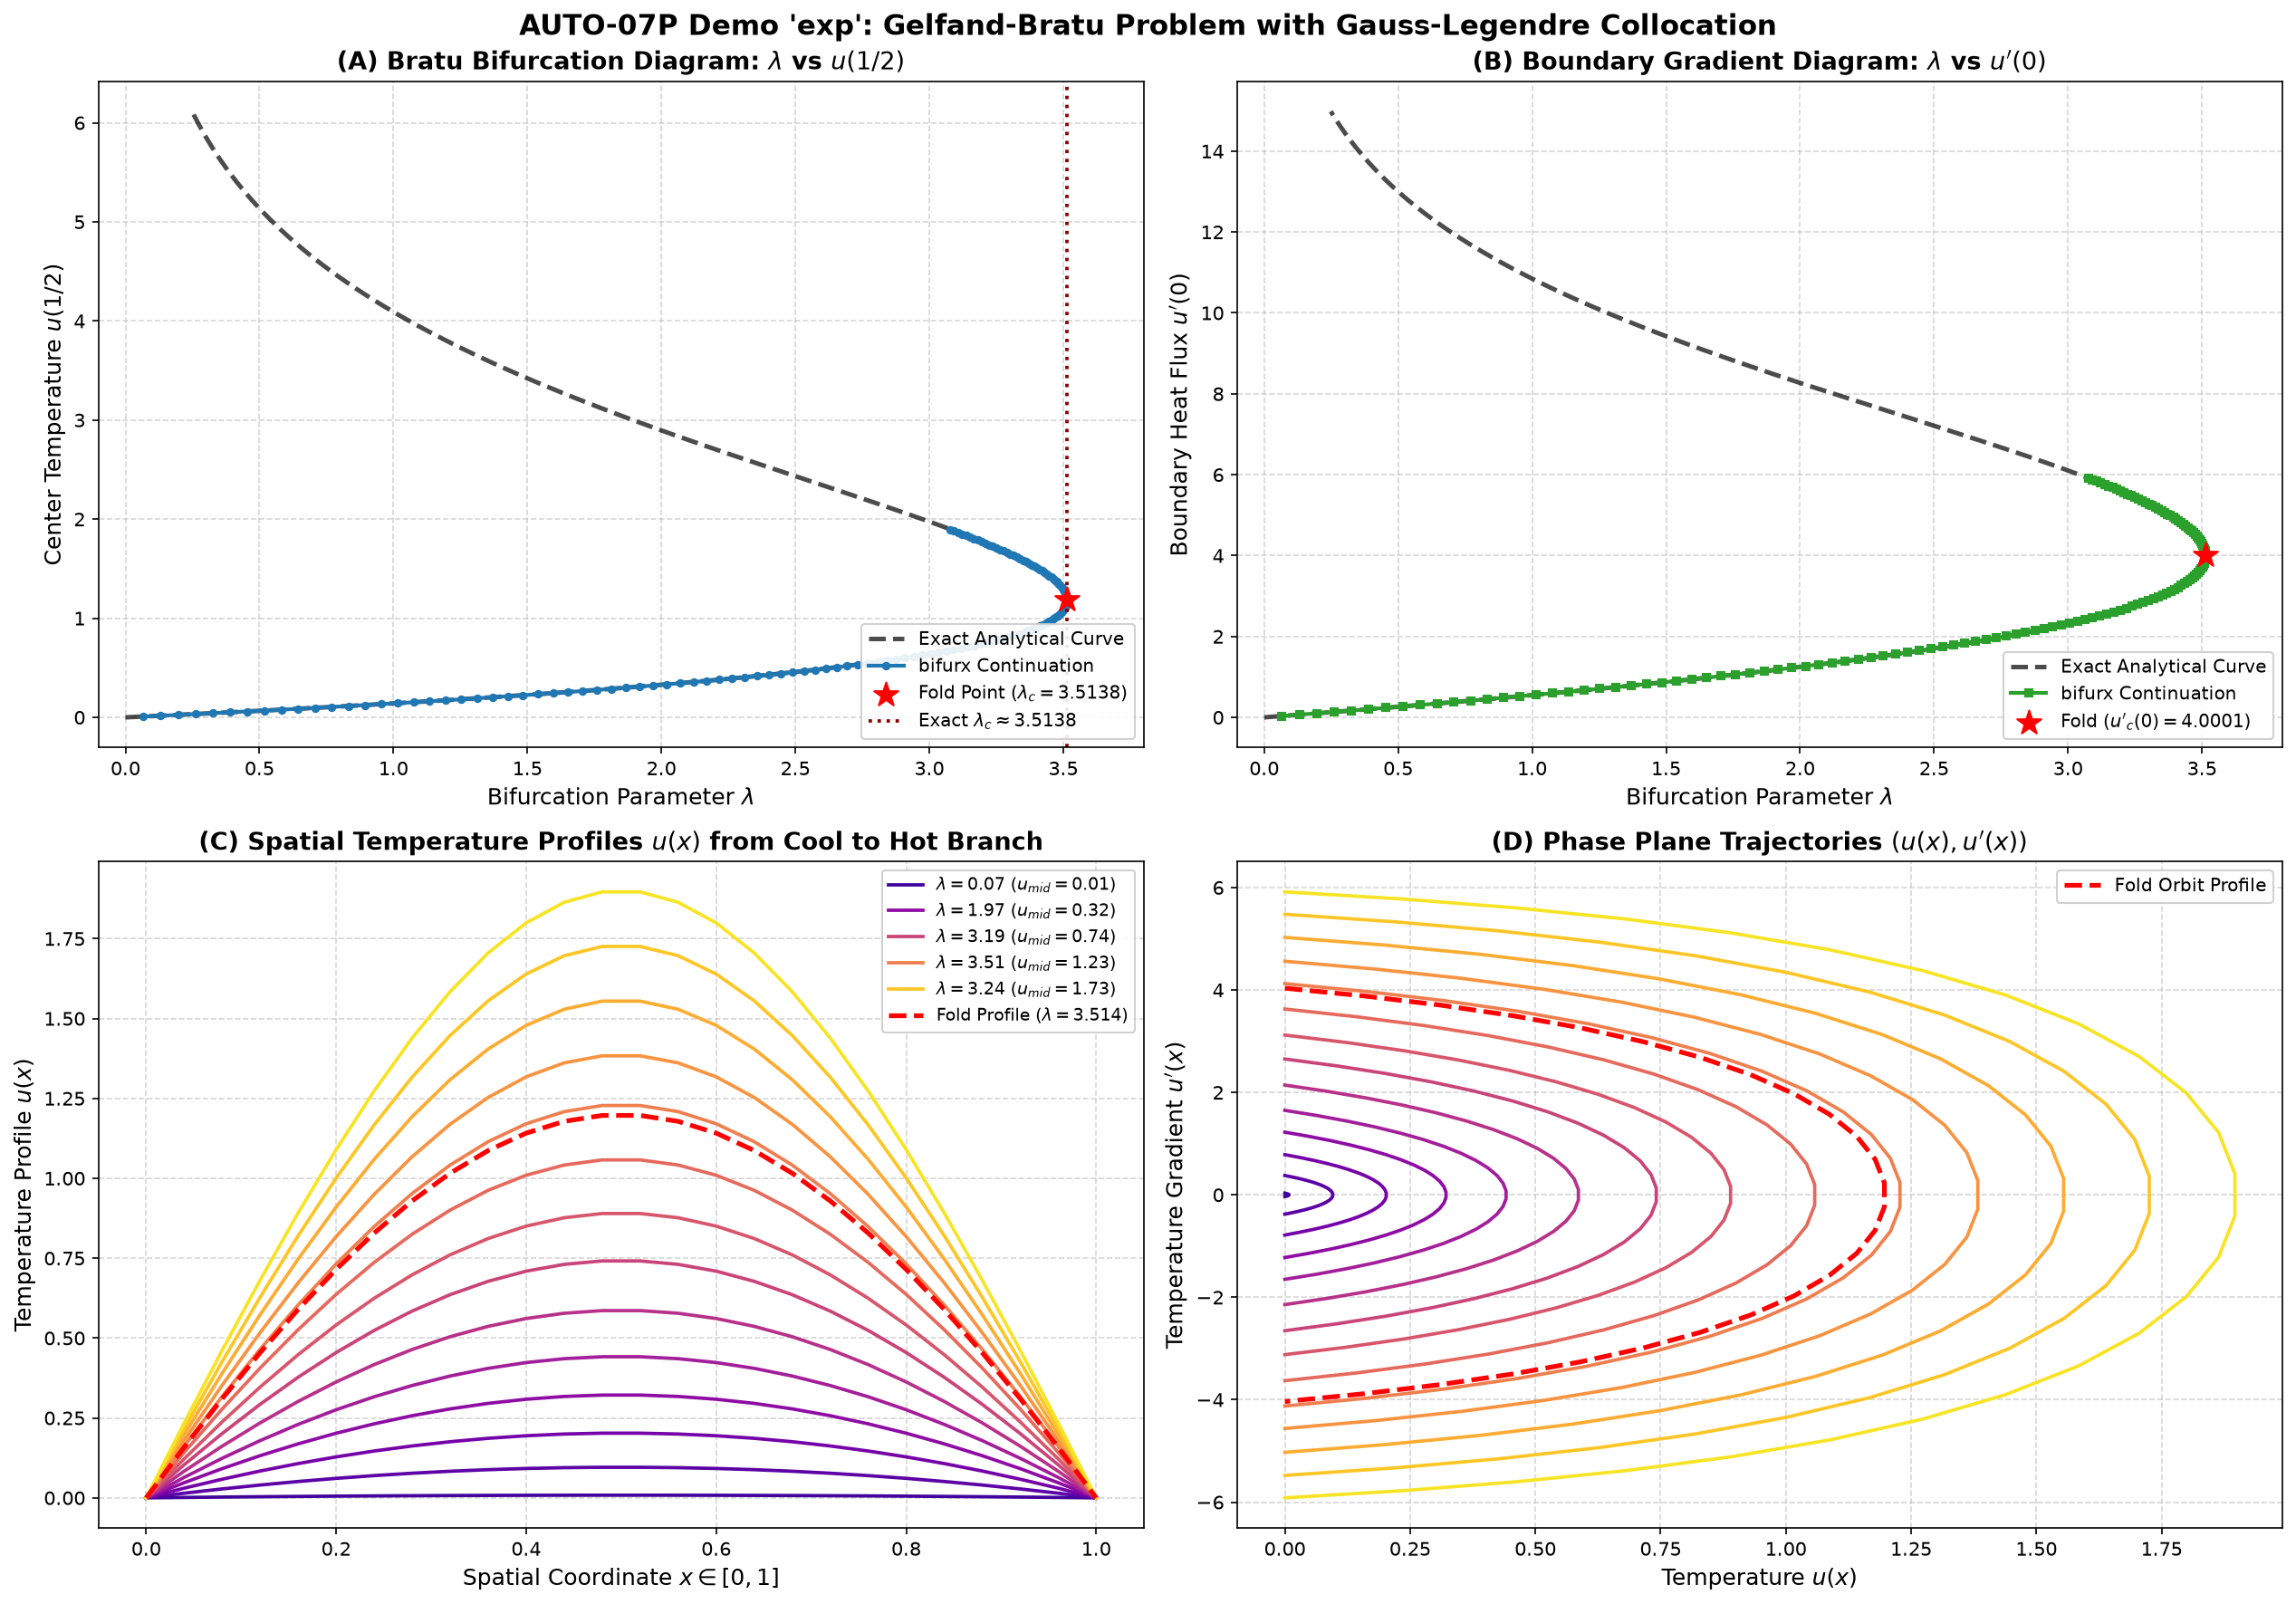

In [6]:
fig = plt.figure(figsize=(17, 12), dpi=150)

num_lams = [h["lambda"] for h in history]
num_u_mids = [h["u_mid"] for h in history]
num_u_primes = [h["u_prime_0"] for h in history]

# -------------------------------------------------------------
# Panel 1: lambda vs u(1/2) Bifurcation Diagram
# -------------------------------------------------------------
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(
    exact_lambdas, exact_u_mids, "k--", linewidth=2.4, alpha=0.7, label="Exact Analytical Curve"
)
ax1.plot(
    num_lams,
    num_u_mids,
    "o-",
    color="#1f77b4",
    linewidth=2.0,
    markersize=3.5,
    label="bifurx Continuation",
)
if fold_detected:
    ax1.scatter(
        [fold_detected["lambda"]],
        [fold_detected["u_mid"]],
        color="red",
        s=180,
        zorder=6,
        marker="*",
        label=rf"Fold Point ($\lambda_c={fold_detected['lambda']:.4f}$)",
    )
ax1.axvline(
    lambda_c,
    color="darkred",
    linestyle=":",
    linewidth=1.8,
    label=rf"Exact $\lambda_c \approx {lambda_c:.4f}$",
)

ax1.set_xlabel(r"Bifurcation Parameter $\lambda$", fontsize=12)
ax1.set_ylabel(r"Center Temperature $u(1/2)$", fontsize=12)
ax1.set_title(r"(A) Bratu Bifurcation Diagram: $\lambda$ vs $u(1/2)$", fontsize=13, weight="bold")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="lower right", framealpha=0.9, fontsize=9.5)
ax1.set_xlim(-0.1, 3.8)

# -------------------------------------------------------------
# Panel 2: lambda vs u'(0) Boundary Flux Diagram
# -------------------------------------------------------------
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(
    exact_lambdas, exact_u_primes, "k--", linewidth=2.4, alpha=0.7, label="Exact Analytical Curve"
)
ax2.plot(
    num_lams,
    num_u_primes,
    "s-",
    color="#2ca02c",
    linewidth=2.0,
    markersize=3.5,
    label="bifurx Continuation",
)
if fold_detected:
    ax2.scatter(
        [fold_detected["lambda"]],
        [fold_detected["u_prime_0"]],
        color="red",
        s=180,
        zorder=6,
        marker="*",
        label=rf"Fold ($u'_c(0)={fold_detected['u_prime_0']:.4f}$)",
    )

ax2.set_xlabel(r"Bifurcation Parameter $\lambda$", fontsize=12)
ax2.set_ylabel(r"Boundary Heat Flux $u'(0)$", fontsize=12)
ax2.set_title(r"(B) Boundary Gradient Diagram: $\lambda$ vs $u'(0)$", fontsize=13, weight="bold")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="lower right", framealpha=0.9, fontsize=9.5)
ax2.set_xlim(-0.1, 3.8)

# -------------------------------------------------------------
# Panel 3: Spatial Solution Profiles u(x)
# -------------------------------------------------------------
ax3 = fig.add_subplot(2, 2, 3)
n_pts = len(history)
cmap = plt.cm.plasma(np.linspace(0.1, 0.95, n_pts))

# Select sample indices along branch
sample_indices = np.linspace(0, n_pts - 1, 14, dtype=int)
for idx in sample_indices:
    h = history[idx]
    is_key = idx in sample_indices[::3]
    lbl = rf"$\lambda={h['lambda']:.2f}$ ($u_{{mid}}={h['u_mid']:.2f}$)" if is_key else None
    ax3.plot(mesh_nodes, h["u1"], color=cmap[idx], linewidth=1.8, label=lbl)

if fold_detected:
    ax3.plot(
        mesh_nodes,
        fold_detected["u1"],
        "r--",
        linewidth=2.5,
        label=rf"Fold Profile ($\lambda={fold_detected['lambda']:.3f}$)",
    )

ax3.set_xlabel(r"Spatial Coordinate $x \in [0, 1]$", fontsize=12)
ax3.set_ylabel(r"Temperature Profile $u(x)$", fontsize=12)
ax3.set_title(
    r"(C) Spatial Temperature Profiles $u(x)$ from Cool to Hot Branch", fontsize=13, weight="bold"
)
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend(loc="upper right", framealpha=0.9, fontsize=9.0)

# -------------------------------------------------------------
# Panel 4: Phase Plane Orbits (u, u')
# -------------------------------------------------------------
ax4 = fig.add_subplot(2, 2, 4)
for idx in sample_indices:
    h = history[idx]
    ax4.plot(h["u1"], h["u2"], color=cmap[idx], linewidth=1.8)

if fold_detected:
    ax4.plot(
        fold_detected["u1"], fold_detected["u2"], "r--", linewidth=2.5, label="Fold Orbit Profile"
    )

ax4.set_xlabel(r"Temperature $u(x)$", fontsize=12)
ax4.set_ylabel(r"Temperature Gradient $u'(x)$", fontsize=12)
ax4.set_title(r"(D) Phase Plane Trajectories $(u(x), u'(x))$", fontsize=13, weight="bold")
ax4.grid(True, linestyle="--", alpha=0.5)
ax4.legend(loc="upper right", framealpha=0.9, fontsize=9.5)

plt.suptitle(
    "AUTO-07P Demo 'exp': Gelfand-Bratu Problem with Gauss-Legendre Collocation",
    fontsize=15,
    weight="bold",
)
plt.tight_layout()
plt.show()